In [54]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.tree import DecisionTreeClassifier 
from sklearn import metrics, tree 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

In [55]:
df = pd.read_csv(
    filepath_or_buffer='data/drug200.csv'
)

df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [80]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [56]:
df_uniques = pd.DataFrame(
    data=[[col, len(df[col].unique())]for col in df.columns],
    columns=['Fuature Name', 'Unique Values Count']
).set_index('Fuature Name')

df_uniques

,Unique Values Count
Fuature Name,
Age,57
Sex,2
BP,3
Cholesterol,2
Na_to_K,198
Drug,5


In [57]:
df.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

In [58]:
X = df[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']].values

X[:5]

array([[23, 'F', 'HIGH', 'HIGH', 25.355],
       [47, 'M', 'LOW', 'HIGH', 13.093],
       [47, 'M', 'LOW', 'HIGH', 10.114],
       [28, 'F', 'NORMAL', 'HIGH', 7.798],
       [61, 'F', 'LOW', 'HIGH', 18.043]], dtype=object)

In [59]:
y = df['Drug']

y[:5]

0    DrugY
1    drugC
2    drugC
3    drugX
4    DrugY
Name: Drug, dtype: object

In [60]:
le_sex = LabelEncoder().fit(df['Sex'].unique())
X[:, 1] = le_sex.fit_transform(X[:, 1])

le_bp = LabelEncoder().fit(df['BP'].unique())
X[:, 2] = le_bp.fit_transform(X[:, 2])

le_chol = LabelEncoder().fit(df['Cholesterol'].unique())
X[:, 3] = le_chol.fit_transform(X[:, 3])

X[:5]

array([[23, 0, 0, 0, 25.355],
       [47, 1, 1, 0, 13.093],
       [47, 1, 1, 0, 10.114],
       [28, 0, 2, 0, 7.798],
       [61, 0, 1, 0, 18.043]], dtype=object)

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [69]:
dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

dt = dt.fit(X_train, y_train)

dt.tree_.node_count, dt.tree_.max_depth

(11, 4)

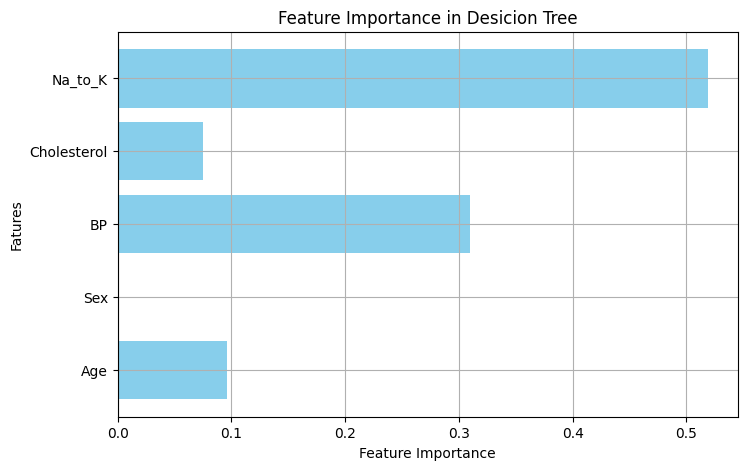

In [63]:
importance = dt.feature_importances_

feature_names = ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']

plt.figure(figsize=(8, 5))

plt.barh(feature_names, importance, color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Fatures')
plt.title('Feature Importance in Desicion Tree')
plt.grid(True)
plt.show()

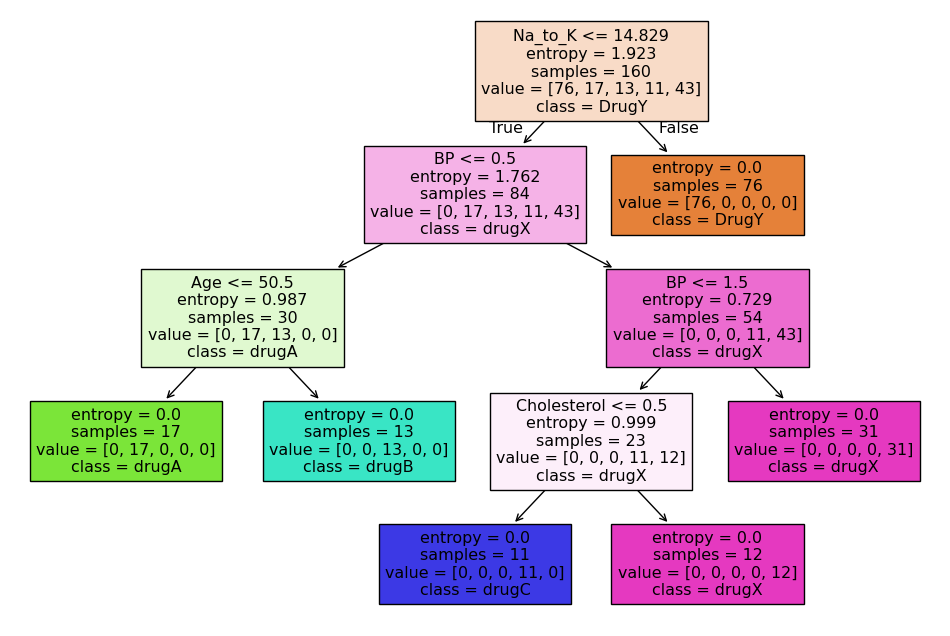

In [64]:
plt.figure(figsize=(12, 8))
tree.plot_tree(
    decision_tree=dt, 
    feature_names=feature_names, 
    class_names=np.unique(y_train), 
    filled=True
)
plt.show()

In [65]:
def measure_model(y_true, y_pred, dataset_name) -> pd.DataFrame:
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    return pd.DataFrame(
        {
            dataset_name: [acc, precision, recall, f1]
        },
        index=['Accuracy', 'Precision', 'Recall', 'F1 Score']
    )

In [66]:
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

train_test_full_evaluate = pd.concat(
    [
        measure_model(y_train, y_train_pred, 'train'),
        measure_model(y_test, y_test_pred, 'test'),
    ],
    axis=1
)

train_test_full_evaluate

,train,test
Accuracy,1.0,1.0
Precision,1.0,1.0
Recall,1.0,1.0
F1 Score,1.0,1.0


In [77]:
param_grid = {
    'max_depth': range(1, dt.tree_.max_depth + 1, 2),
    'max_features': range(1, len(dt.feature_importances_) + 1)
}

GR = GridSearchCV(
    DecisionTreeClassifier(
        random_state=42,
        criterion='entropy'
    ),
    param_grid=param_grid,
    scoring='accuracy',
    n_jobs=-1
)

GR = GR.fit(X_train, y_train)

print(
    f'Node Count: {GR.best_estimator_.tree_.node_count}\n'
    f'Max Depth: {GR.best_estimator_.tree_.max_depth}\n'
    f'{GR.best_estimator_.criterion}\n'
)

Node Count: 9
Max Depth: 3
entropy



In [78]:
y_train_pred_gr = GR.predict(X_train)
y_test_pred_gr = GR.predict(X_test)

gr_evaluate = pd.concat(
    [
        measure_model(y_train, y_train_pred_gr, 'train'),
        measure_model(y_test, y_test_pred_gr, 'test'),
    ],
    axis=1
)

gr_evaluate

,train,test
Accuracy,0.931250,0.875000
Precision,0.759259,0.737500
Recall,0.800000,0.800000
F1 Score,0.777320,0.762963


In [ ]:
dt_final = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3
)

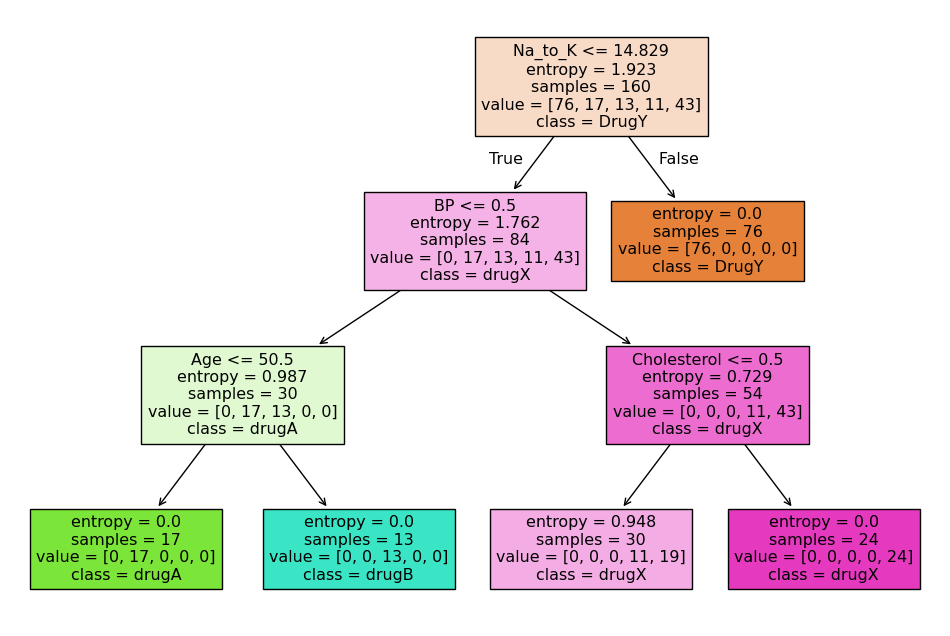

In [79]:
plt.figure(figsize=(12, 8))
tree.plot_tree(
    decision_tree=GR.best_estimator_,
    feature_names=feature_names, 
    class_names=np.unique(y_train), 
    filled=True
)
plt.show()